# Worksheet 4 — Fully Connected Neural Network for Devnagari Digit Classification

### Setup

In [1]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.utils import to_categorical
from tensorflow import keras
from sklearn.utils import shuffle

print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

TensorFlow version: 2.19.0
Keras version: 3.13.2


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Task 1- Data preperation

In [3]:
train_dir = "/content/drive/MyDrive/Ai final sem/Week 4/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/Ai final sem/Week 4/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test/"

In [6]:
img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            img = Image.open(img_path).convert("L")
            img = img.resize((img_width, img_height))
            img = np.array(img) / 255.0

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

x_train, y_train = shuffle(x_train, y_train, random_state=42)
x_test,  y_test  = shuffle(x_test,  y_test,  random_state=42)

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# one hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test  = to_categorical(y_test,  num_classes=10)

print(f"Training set:  {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set:   {x_test.shape},  Labels: {y_test.shape}")

Training set:  (17000, 28, 28, 1), Labels: (17000, 10)
Testing set:   (3000, 28, 28, 1),  Labels: (3000, 10)


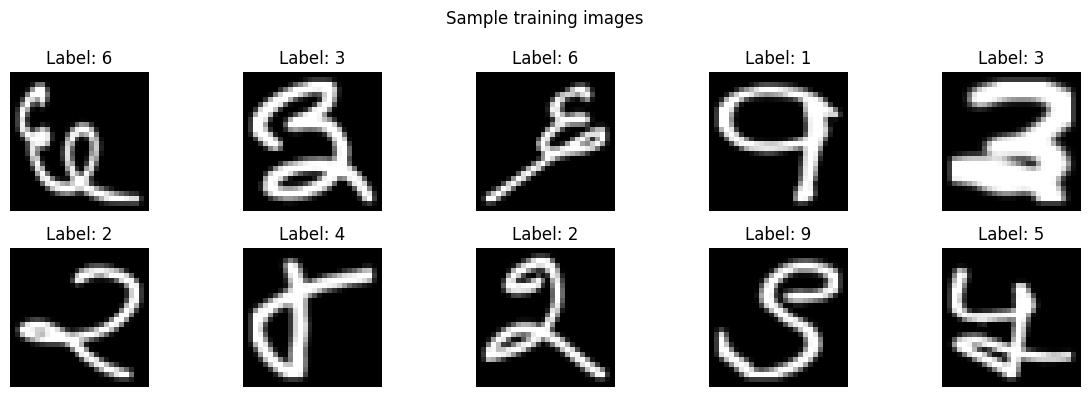

In [7]:
# Visualise sample images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.suptitle('Sample training images')
plt.tight_layout()
plt.show()

### Task 2- Build the FCN Model

In [18]:
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(64,  activation='sigmoid'),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(256, activation='sigmoid'),
    keras.layers.Dense(10,  activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

### Task 3- compile the model

In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Task 4- Train the model

In [13]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_devnagari_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2431 - loss: 2.1827
Epoch 1: val_accuracy improved from None to 0.71324, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4291 - loss: 1.8713 - val_accuracy: 0.7132 - val_loss: 1.0558
Epoch 2/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7953 - loss: 0.8095
Epoch 2: val_accuracy improved from 0.71324 to 0.85029, saving model to best_devnagari_model.keras

Epoch 2: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8204 - loss: 0.6553 - val_accuracy: 0.8503 - val_loss: 0.4572
Epoch 3/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8802 - loss: 0.3873
Epoch 3: val_accuracy improved from 0.85029 to 0.91471, saving model to best_devnagari_model.keras

Epoch 3: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━

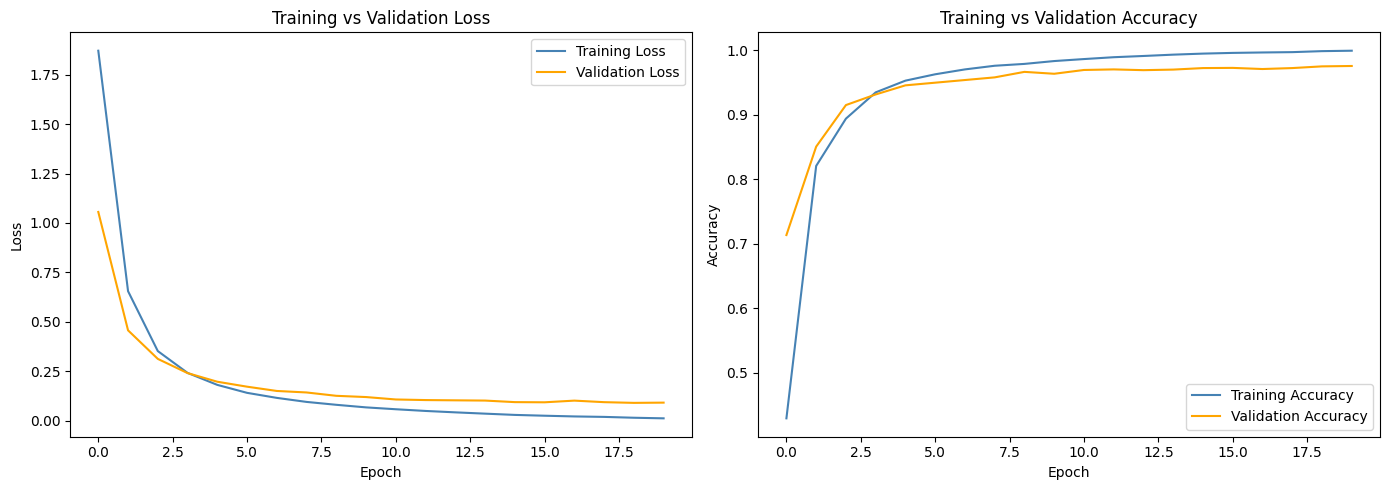

In [14]:
# Plot training & validation loss and accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Training Loss',     color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss',   color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Training Accuracy',   color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

### Task 5- Evaluate the model

In [15]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

94/94 - 0s - 4ms/step - accuracy: 0.9803 - loss: 0.0856
Test Accuracy: 0.9803
Test Loss:     0.0856


### Task 6- save and load the model

In [16]:
# Save
model.save('devnagari_model.h5')
print('Model saved to devnagari_model.h5')

# Load
loaded_model = tf.keras.models.load_model('devnagari_model.h5')
print('Model loaded successfully')

# Re-evaluate
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"Loaded Model — Test Accuracy: {loaded_acc:.4f}, Test Loss: {loaded_loss:.4f}")

Model saved to devnagari_model.h5
Model loaded successfully
94/94 - 1s - 7ms/step - accuracy: 0.9803 - loss: 0.0856
Loaded Model — Test Accuracy: 0.9803, Test Loss: 0.0856


### Task 7- Make Predictions

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
First 10 predicted labels: [6 3 6 0 8 3 4 0 1 8]
First 10 true labels:      [6 3 6 0 8 3 4 7 1 8]


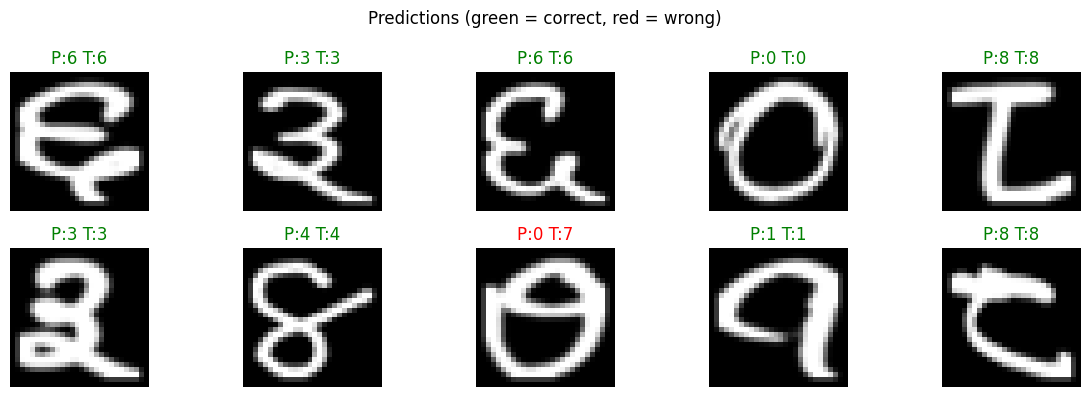

In [17]:
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test, axis=1)

print("First 10 predicted labels:", predicted_labels[:10])
print("First 10 true labels:     ", true_labels[:10])

# Visualise predictions on a sample of test images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    colour = 'green' if predicted_labels[i] == true_labels[i] else 'red'
    plt.title(f"P:{predicted_labels[i]} T:{true_labels[i]}", color=colour)
    plt.axis('off')
plt.suptitle('Predictions (green = correct, red = wrong)')
plt.tight_layout()
plt.show()